In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yazanalshuaibi/gas-furnace")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gas-furnace' dataset.
Path to dataset files: /kaggle/input/gas-furnace


In [ ]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path,"gas-furnace.csv"))

In [ ]:
df = df[["CO2"]]
df.head()

,CO2
0,53.8
1,53.6
2,53.5
3,53.5
4,53.4


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CO2     296 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB


In [ ]:
df.describe()


,CO2
count,296.000000
mean,53.509122
std,3.202121
min,45.600000
25%,51.200000
50%,53.500000
75%,56.000000
max,60.500000


In [ ]:
df.reset_index(drop=True, inplace=True)
df.head()


,CO2
0,53.8
1,53.6
2,53.5
3,53.5
4,53.4


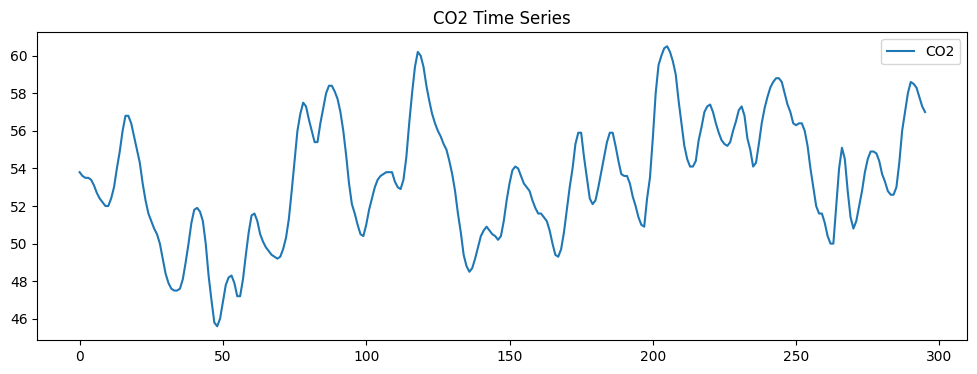

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["CO2"], label="CO2")
plt.legend()
plt.title("CO2 Time Series")
plt.show()

<Figure size 640x480 with 0 Axes>

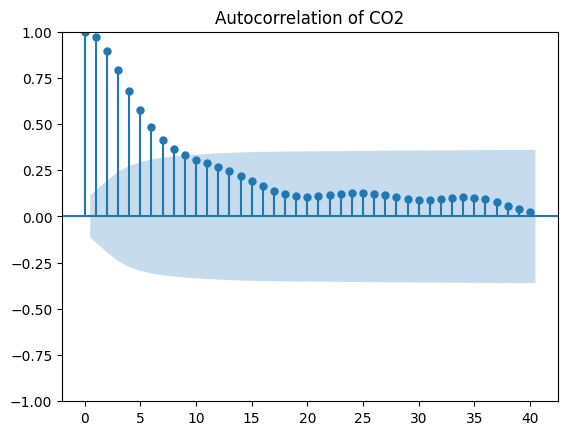

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(df["CO2"], lags=40)
plt.title("Autocorrelation of CO2")
plt.show()

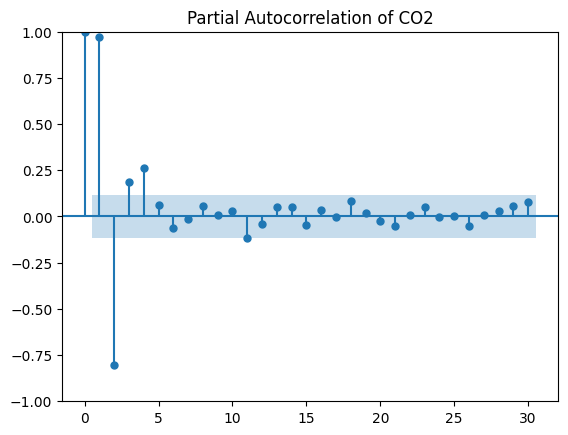

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["CO2"], lags=30)
plt.title("Partial Autocorrelation of CO2")
plt.show()

In [ ]:
def time_split(df, test_size=0.2):
    df.index = pd.date_range("2026-01-01", periods=len(df), freq="1s")
    n = len(df)
    split = int((1 - test_size) * n)
    return df.iloc[:split], df.iloc[split:]

In [ ]:
train, test = time_split(df)

In [ ]:
train

,CO2
2026-01-01 00:00:00,53.8
2026-01-01 00:00:01,53.6
2026-01-01 00:00:02,53.5
2026-01-01 00:00:03,53.5
2026-01-01 00:00:04,53.4
...,...
2026-01-01 00:03:51,57.3
2026-01-01 00:03:52,56.8
2026-01-01 00:03:53,55.6
2026-01-01 00:03:54,55.0


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(
    train["CO2"],
    order=(3, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = arima.fit()

fit_ext = arima_fit.apply(df["CO2"])

pred = fit_ext.get_prediction(start=int(0.8 * len(df)), end=len(df)-1, dynamic=False)

yhat_arima = pred.predicted_mean.to_numpy()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, yhat_arima)
print(f"ARIMA(3,0,1) MAE: {mae:.4f}")

ARIMA(3,0,1) MAE: 0.2994


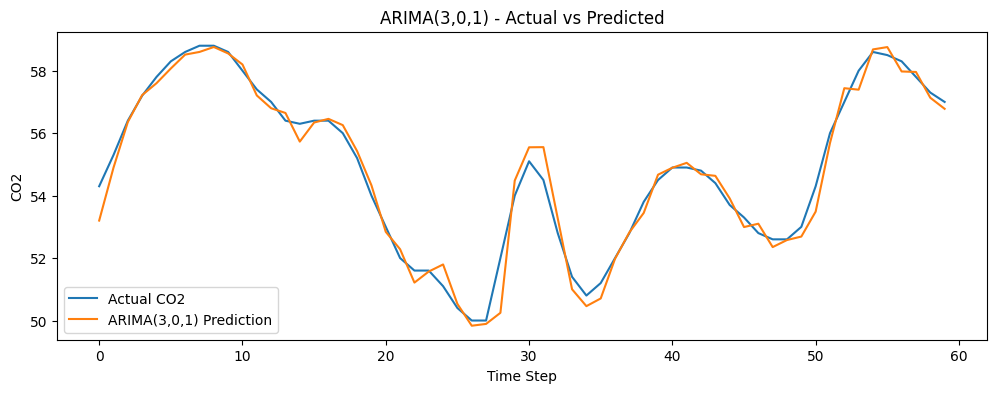

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(len(test)), test, label="Actual CO2")
plt.plot(range(len(yhat_arima)), yhat_arima, label="ARIMA(3,0,1) Prediction")
plt.legend()
plt.title("ARIMA(3,0,1) - Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("CO2")
plt.show()